# The Evolving Face of Cyber Threats: A Global Perspective (2015–2024)

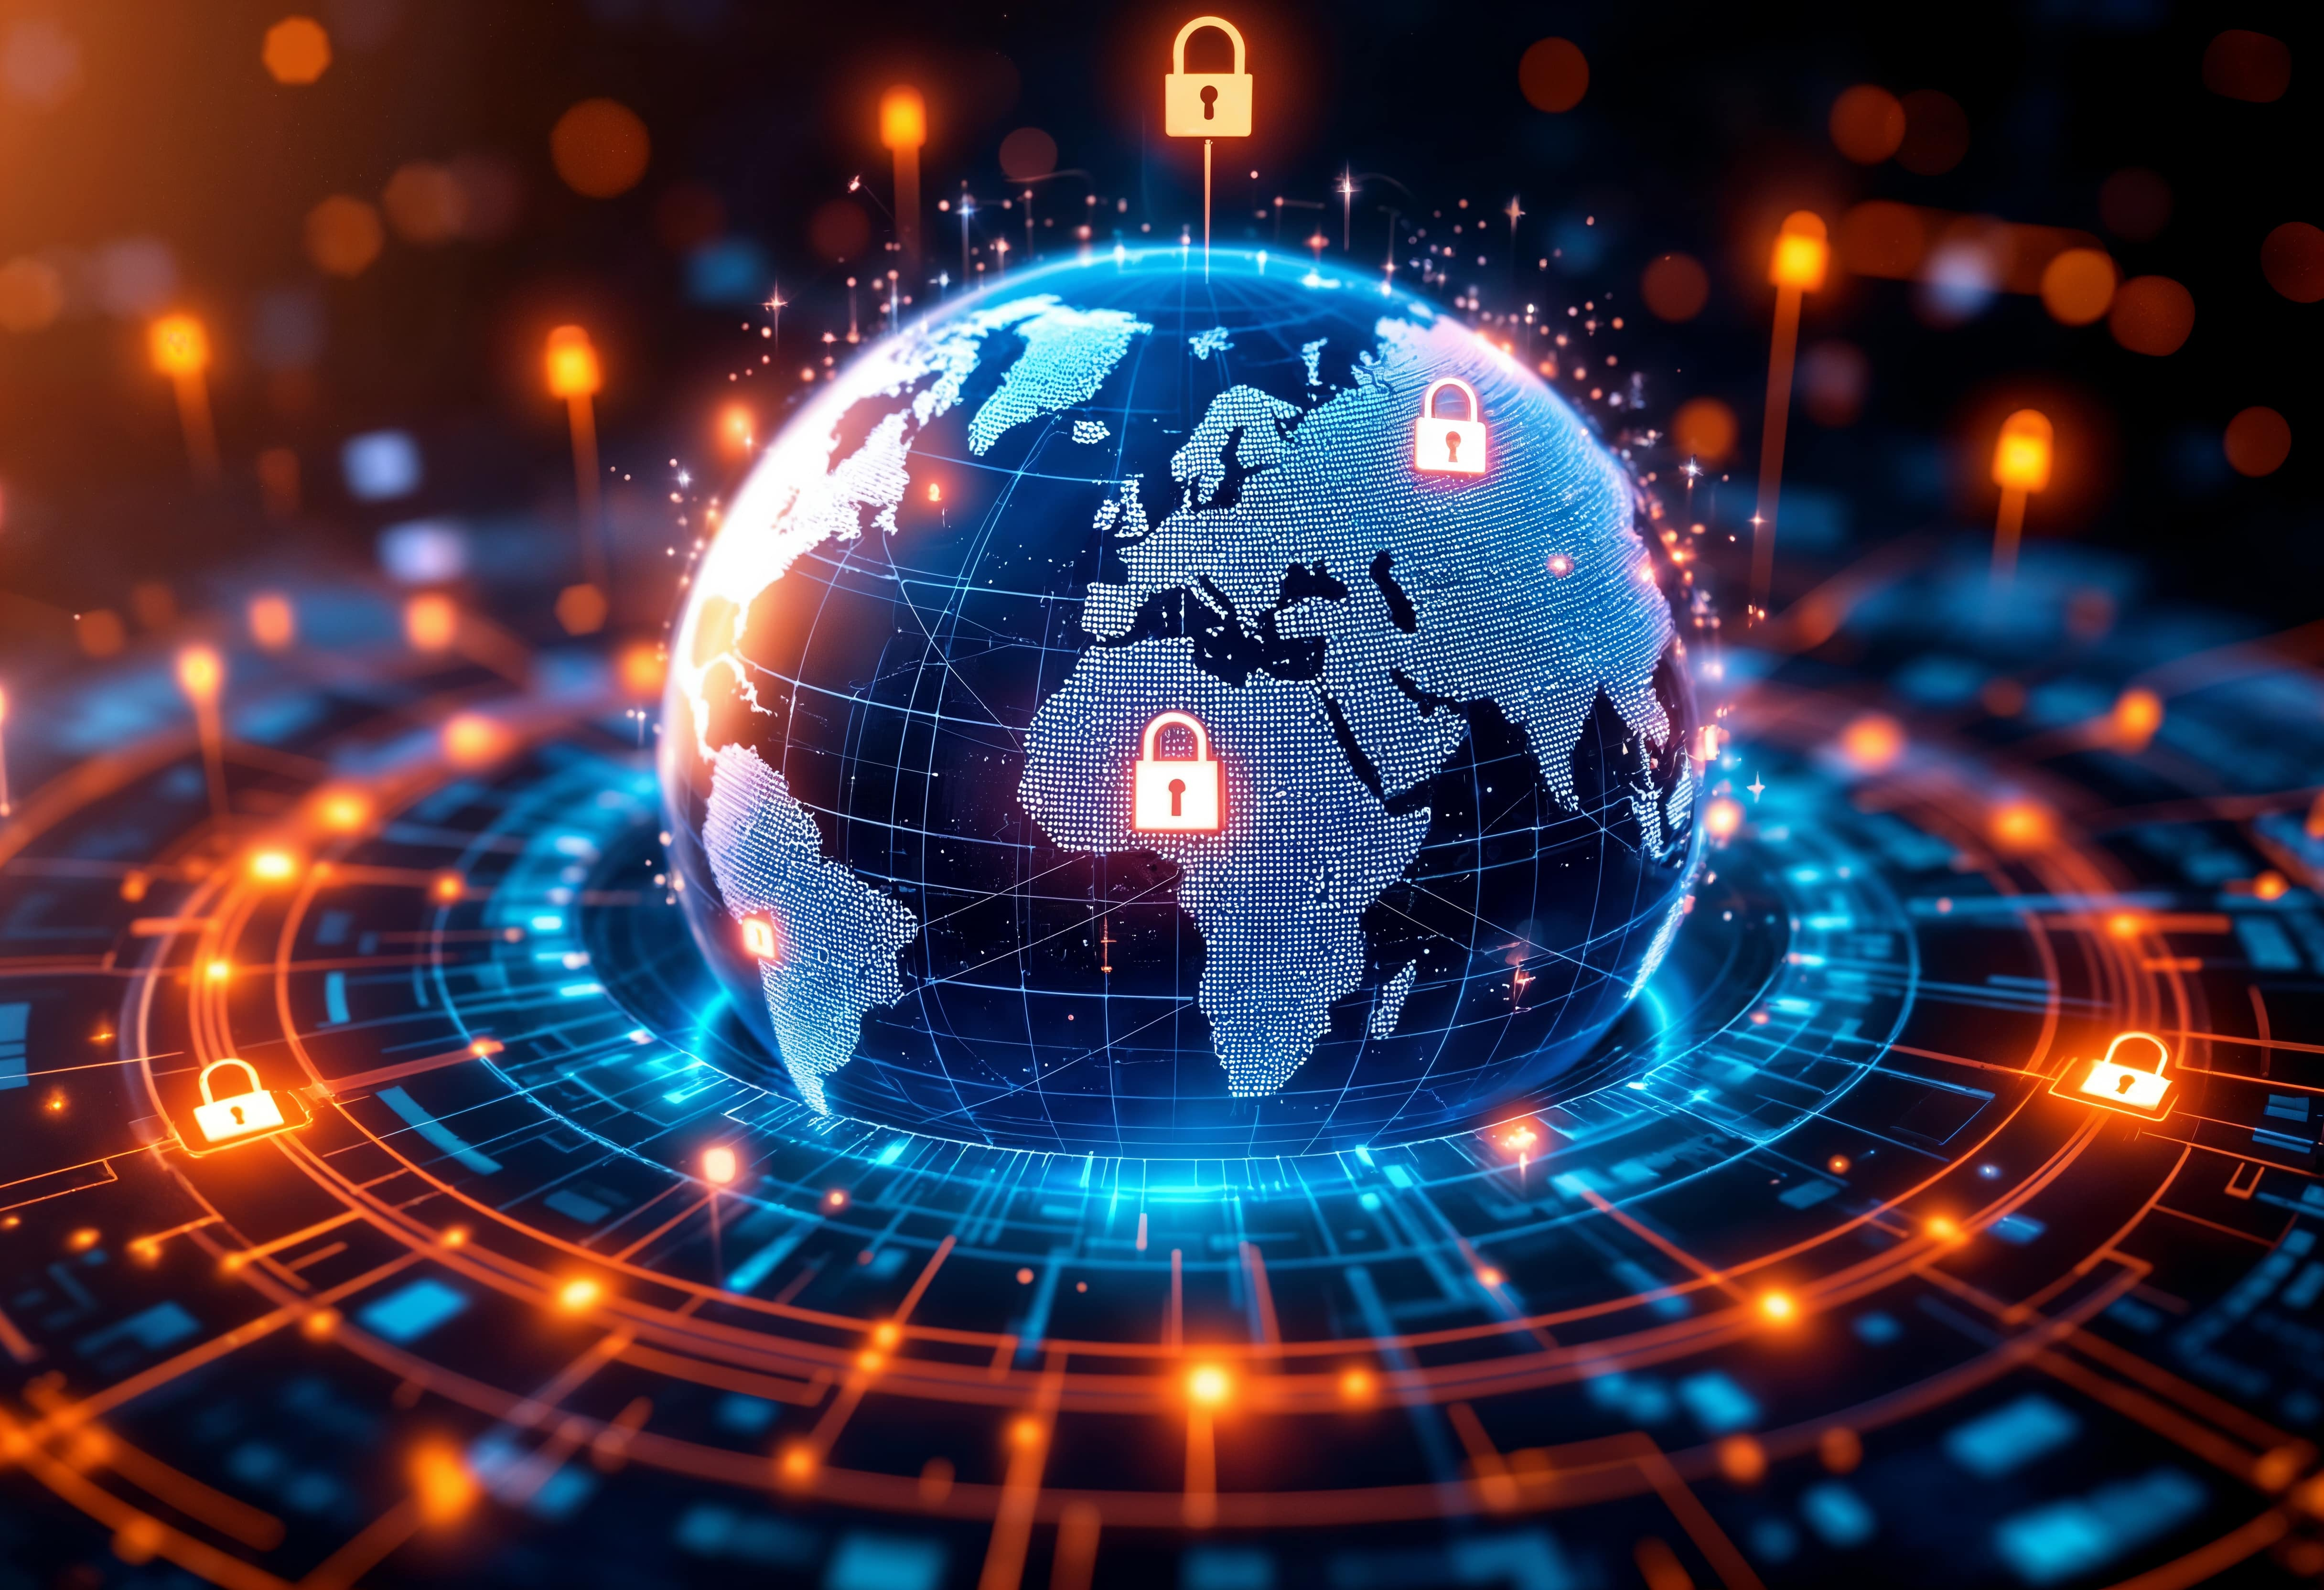

## Purpose of the Dataset
This dataset provides detailed information on cybersecurity incidents across different industries and countries. It includes variables such as attack type, target industry, attack source, financial loss, number of affected users, incident resolution time, and defense mechanisms used. The dataset is useful for analyzing trends in cyber-attacks and understanding their impacts on organizations globally.

## Problem Statement
As cyber threats continue to evolve, organizations face increasing challenges in predicting, preventing, and mitigating cyber-attacks. There is a critical need for data-driven insights to identify the most common attack types, vulnerable industries, and the financial and operational impact of these incidents. Without such insights, companies remain exposed to significant security risks and financial losses.

## Key Business Questions 

- Which countries are most frequently targeted by cyber-attacks globally.

- What is the global financial loss associated with different types of cyber-attacks

- What are the main sources of these cyber threats?

- How do different countries compare in terms of the number of affected users

- What is the average incident resolution time across various countries and industries?

- Which defense mechanisms are most widely used and how effective are they?


In [6]:
# Import required librabries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report


In [7]:
# Loading the dataset
dataset = pd.read_csv("Global_Cybersecurity_Threats_2015-2024.csv")

In [61]:
dataset.head(10)

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,2,2019,3,1,80.53,773169,0,1,4,63
1,2,2019,4,5,62.19,295961,0,1,3,71
2,5,2017,2,4,38.65,605895,0,2,4,20
3,8,2024,4,6,41.44,659320,2,0,0,7
4,4,2018,2,4,74.41,810682,1,0,4,68
5,4,2017,2,5,98.24,285201,3,0,1,25
6,4,2016,0,6,33.26,431262,1,1,4,34
7,3,2018,5,2,59.23,909991,3,0,1,66
8,5,2016,2,0,16.88,698249,3,0,4,47
9,8,2023,0,3,69.14,685927,0,1,3,58


In [9]:
dataset.tail(10)

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
2990,France,2015,Phishing,Telecommunications,65.16,998011,Unknown,Zero-day,Encryption,14
2991,Russia,2019,Ransomware,Banking,28.14,594170,Nation-state,Social Engineering,AI-based Detection,53
2992,UK,2021,Malware,Banking,60.14,191427,Nation-state,Zero-day,Encryption,56
2993,Germany,2017,SQL Injection,Education,54.98,786577,Insider,Unpatched Software,Firewall,70
2994,Germany,2019,Ransomware,Government,58.60,76066,Insider,Unpatched Software,AI-based Detection,8
2995,UK,2021,Ransomware,Government,51.42,190694,Unknown,Social Engineering,Firewall,52
2996,Brazil,2023,SQL Injection,Telecommunications,30.28,892843,Hacker Group,Zero-day,VPN,26
2997,Brazil,2017,SQL Injection,IT,32.97,734737,Nation-state,Weak Passwords,AI-based Detection,30
2998,UK,2022,SQL Injection,IT,32.17,379954,Insider,Unpatched Software,Firewall,9
2999,Germany,2021,SQL Injection,Retail,48.20,480984,Unknown,Zero-day,VPN,64


In [10]:
# Checking the shape of the dataset
dataset.shape

(3000, 10)

In [11]:
# Checking the columns in the dataset
dataset.columns

Index(['Country', 'Year', 'Attack Type', 'Target Industry',
       'Financial Loss (in Million $)', 'Number of Affected Users',
       'Attack Source', 'Security Vulnerability Type',
       'Defense Mechanism Used', 'Incident Resolution Time (in Hours)'],
      dtype='object')

In [12]:
# Check for missing values
dataset.isna().sum()

Country                                0
Year                                   0
Attack Type                            0
Target Industry                        0
Financial Loss (in Million $)          0
Number of Affected Users               0
Attack Source                          0
Security Vulnerability Type            0
Defense Mechanism Used                 0
Incident Resolution Time (in Hours)    0
dtype: int64

In [13]:
# Check for any duplicate rows in the dataset
dataset.duplicated().any()

False

In [14]:
# Inspecting the data
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Country                              3000 non-null   object 
 1   Year                                 3000 non-null   int64  
 2   Attack Type                          3000 non-null   object 
 3   Target Industry                      3000 non-null   object 
 4   Financial Loss (in Million $)        3000 non-null   float64
 5   Number of Affected Users             3000 non-null   int64  
 6   Attack Source                        3000 non-null   object 
 7   Security Vulnerability Type          3000 non-null   object 
 8   Defense Mechanism Used               3000 non-null   object 
 9   Incident Resolution Time (in Hours)  3000 non-null   int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 234.5+ KB


In [15]:
# List of columns to convert
categorical_columns = [
    'Attack Type',
    'Target Industry',
    'Attack Source',
    'Security Vulnerability Type',
    'Defense Mechanism Used'
]

# Convert each column to category type
for col in categorical_columns:
    dataset[col] = dataset[col].astype('category')

print(dataset.dtypes)

Country                                  object
Year                                      int64
Attack Type                            category
Target Industry                        category
Financial Loss (in Million $)           float64
Number of Affected Users                  int64
Attack Source                          category
Security Vulnerability Type            category
Defense Mechanism Used                 category
Incident Resolution Time (in Hours)       int64
dtype: object


## Exploratory Data Analysis

In [17]:
# Summary statistics
dataset.describe()

,Year,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours)
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,2019.570333,50.492970,504684.136333,36.476000
std,2.857932,28.791415,289944.084972,20.570768
min,2015.000000,0.500000,424.000000,1.000000
25%,2017.000000,25.757500,255805.250000,19.000000
50%,2020.000000,50.795000,504513.000000,37.000000
75%,2022.000000,75.630000,758088.500000,55.000000
max,2024.000000,99.990000,999635.000000,72.000000


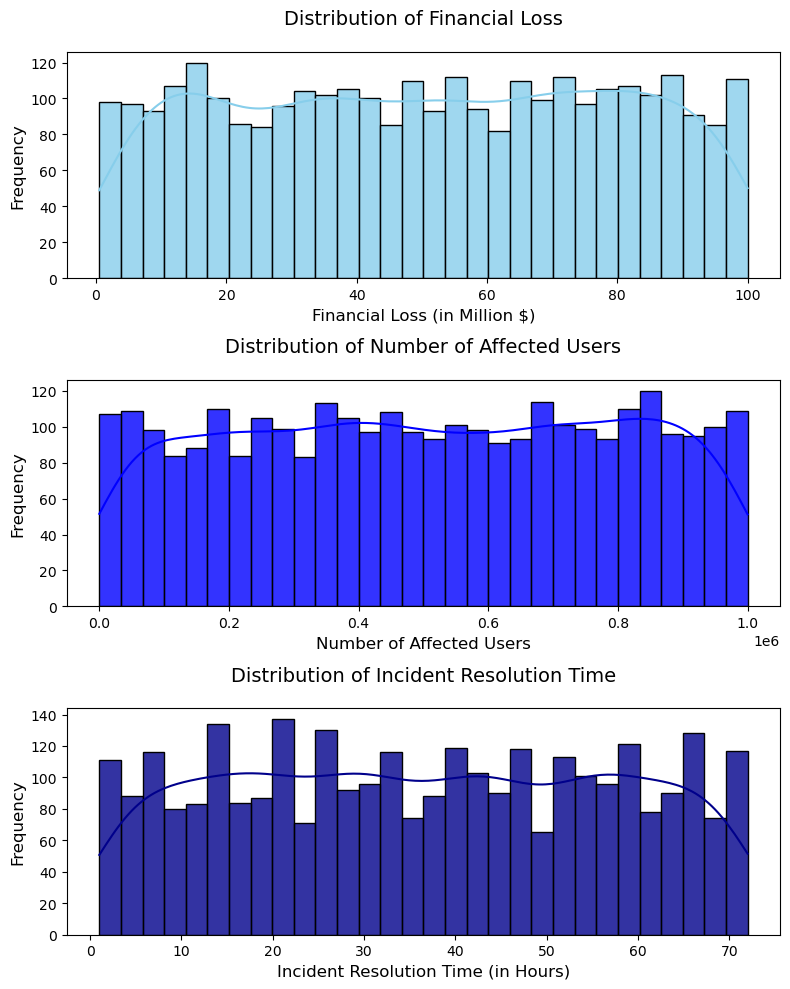

In [18]:
plt.figure(figsize=(8, 10))

# Financial Loss
plt.subplot(3, 1, 1)
sns.histplot(
    dataset['Financial Loss (in Million $)'], 
    bins=30, 
    kde=True, 
    color='skyblue',
    edgecolor='black',
    linewidth=1,
    alpha=0.8
)
plt.title('Distribution of Financial Loss', fontsize=14, pad=20)
plt.xlabel('Financial Loss (in Million $)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.ylim(0, None)  # Start y-axis at 0 but auto-adjust max height

# Number of Affected Users
plt.subplot(3, 1, 2)
sns.histplot(
    dataset['Number of Affected Users'], 
    bins=30, 
    kde=True, 
    color='blue',
    edgecolor='black',
    linewidth=1,
    alpha=0.8
)
plt.title('Distribution of Number of Affected Users', fontsize=14, pad=20)
plt.xlabel('Number of Affected Users', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.ylim(0, None)  # Extend y-axis upward

# Incident Resolution Time
plt.subplot(3, 1, 3)
sns.histplot(
    dataset['Incident Resolution Time (in Hours)'], 
    bins=30, 
    kde=True, 
    color='darkblue',
    edgecolor='black',
    linewidth=1,
    alpha=0.8
)
plt.title('Distribution of Incident Resolution Time', fontsize=14, pad=20)
plt.xlabel('Incident Resolution Time (in Hours)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.ylim(0, None)  # Let the bars stretch taller

plt.tight_layout()
plt.show()

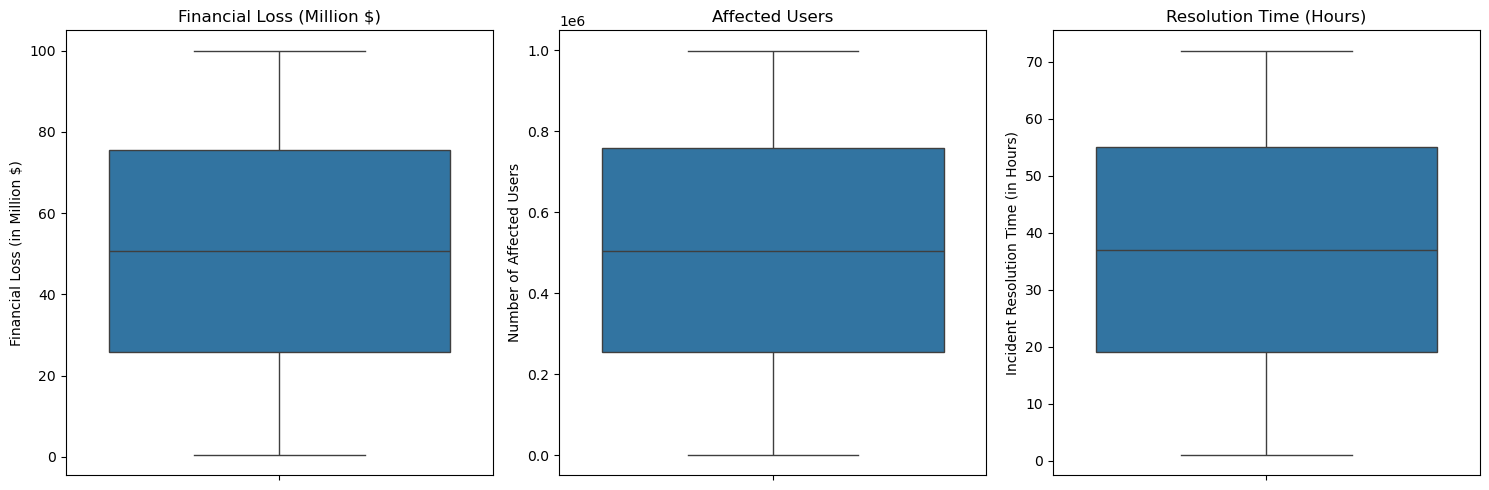

In [19]:
# Custom colors and explode for emphasis
colors = ['#00FFFF', '#0000FF', '#00008B']

# Create boxplots for each numeric column
plt.figure(figsize=(15, 5))

# Financial Loss
plt.subplot(1, 3, 1)
sns.boxplot(y=dataset['Financial Loss (in Million $)'])
plt.title('Financial Loss (Million $)')

# Affected Users
plt.subplot(1, 3, 2)
sns.boxplot(y=dataset['Number of Affected Users'])
plt.title('Affected Users')

# Resolution Time
plt.subplot(1, 3, 3)
sns.boxplot(y=dataset['Incident Resolution Time (in Hours)'])
plt.title('Resolution Time (Hours)')

plt.tight_layout()
plt.show()

# KEY BUSINESS INSIGHTS

## 1. Countries Targeted By Cyber-Attacks Globally.

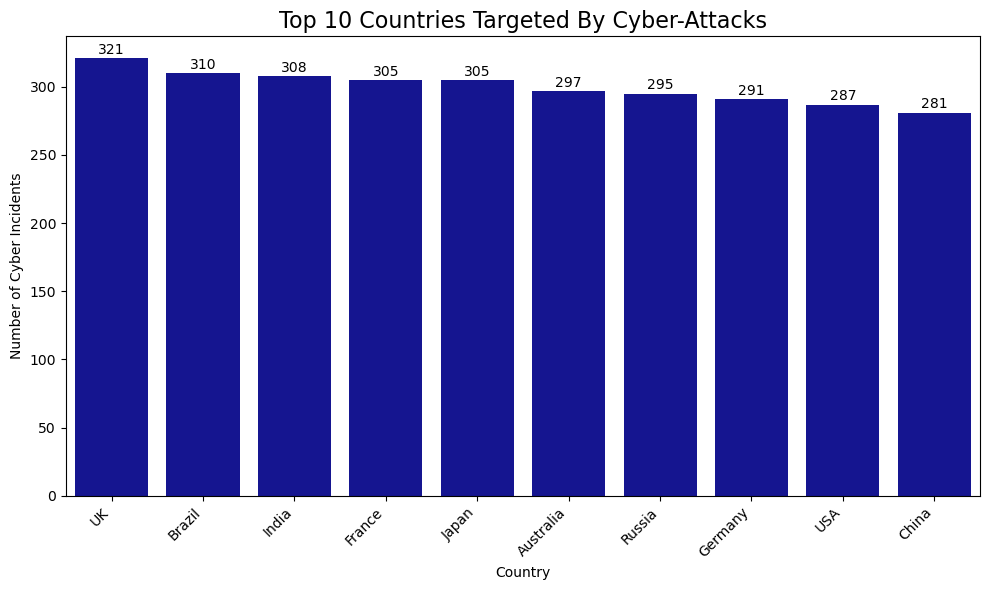

In [21]:
# Get the top 10 countries by number of attacks
top_countries = dataset['Country'].value_counts().head(10)

# Plot vertical bar chart
plt.figure(figsize=(10, 6))
barplot = sns.barplot(x=top_countries.index, y=top_countries.values, color='#0000A5')

# Add data labels
for i, value in enumerate(top_countries.values):
    plt.text(i, value + 1, str(value), ha='center', va='bottom', fontsize=10)

# Chart details
plt.title('Top 10 Countries Targeted By Cyber-Attacks', fontsize=16)
plt.xlabel('Country')
plt.ylabel('Number of Cyber Incidents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Findings:
- The UK has the highest number of reported cyber incidents, slightly above the rest.
- Other countries such as Brazil, India, France, Japan, and Australia also show high levels of incidents.
- The USA and China, despite being major cyber hubs, are near the bottom of this specific chart, but still have high incident levels.
- 

  
### Recommendation:
- Encourage global cooperation for intelligence sharing and rapid response frameworks.
- Promote cross-border law enforcement collaboration to track and prevent cybercrime.
- Countries should invest in cybersecurity research, threat detection systems, and skilled personnel.




## 2. Financial Loss Associated with the Types of Cyber-Attacks

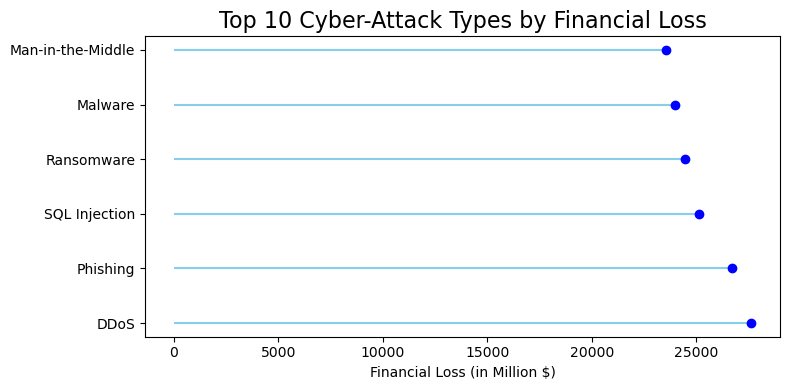

In [24]:

# Calculate total financial loss per attack type
loss_by_attack = dataset.groupby('Attack Type')['Financial Loss (in Million $)'].sum().sort_values(ascending=False).head(10)

# Lollipop chart
plt.figure(figsize=(8, 4))
plt.hlines(y=loss_by_attack.index, xmin=0, xmax=loss_by_attack.values, color='skyblue')
plt.plot(loss_by_attack.values, loss_by_attack.index, "o", color='blue')
plt.title("Top 10 Cyber-Attack Types by Financial Loss", fontsize=16)
plt.xlabel("Financial Loss (in Million $)")
plt.tight_layout()
plt.show()

### Findings:
- DDoS (Distributed Denial-of-Service) attacks cause the highest financial loss.
- Phishing and SQL Injection are also major contributors to financial losses.
- Ransomware, Malware, and Man-in-the-Middle attacks follow closely with similar levels of losses.
- The financial impact across these six types is quite high and closely grouped, indicating all are significant threats. 


### Recommendation:
- Conduct regular risk assessments and penetration tests.
- Invest in DDoS mitigation services (e.g., rate limiting, traffic filtering).
- Ensure anti-virus software and systems are regularly updated.

## 3. The Main Sources of Cyber Threats

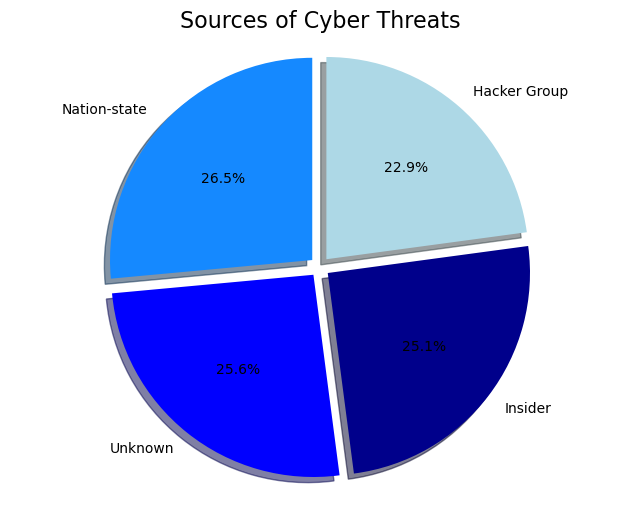

In [27]:
# Count the frequency of each Attack Source
attack_counts = dataset['Attack Source'].value_counts()

# Custom colors and explode for emphasis
colors = ['#1589FF', '#0000FF', '#00008B', '#ADD8E6']
explode = [0.05] * len(attack_counts)  # Slightly separate all slices

# Plot the pie chart
plt.figure(figsize=(8, 6))
plt.pie(
    x=attack_counts.values,  # <- Actual values for the pie chart
    labels=attack_counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=colors[:len(attack_counts)], 
    explode=explode[:len(attack_counts)],
    shadow=True
)
plt.title('Sources of Cyber Threats', fontsize=16)
plt.axis('equal')  # Keeps the pie chart as a circle
plt.show()


### Findings:
- Nation-state attacks account for the highest percentage (26.5%), suggesting an increasing use of cyber tactics in geopolitical conflicts.
- Hacker Groups, although slightly lower in percentage, still pose a significant threat (22.9%) and are often behind ransomware and DDoS attacks.
- Insider threats and Unknown sources together represent over 50%, highlighting a major blind spot in threat detection and employee monitoring. 


### Recommendation:
- Industries should prioritize strengthening internal security by implementing role-based access controls, continuous employee monitoring, and regular cybersecurity awareness training to mitigate insider threats.
- Investment in advanced threat intelligence tools and digital forensics is crucial to improve attribution and reduce the number of attacks from unknown sources. 

## 4. Comparing Countries in Terms of the Number of Affected Users

In [30]:
import plotly.express as px

# Group by country and sum affected users
country_impact = dataset.groupby('Country')['Number of Affected Users'].sum().reset_index()

# Plot choropleth map with blue color scale
fig = px.choropleth(
    country_impact,
    locations='Country',
    locationmode='country names',
    color='Number of Affected Users',
    color_continuous_scale='Blues',
    title='Global Distribution of Affected Users by Country',
)

fig.update_layout(geo=dict(showframe=False, showcoastlines=True))
fig.show()


### Findings:
- The choropleth map highlights that certain countries have experienced significantly higher numbers of affected users due to cyber incidents.
- Countries such as Brazil, United Kingdom and France show higher number of affected users.
- Some highly digitized nations show moderate impact, suggesting stronger security frameworks or better incident response systems. 


### Recommendation:
- Governments and organizations in high-impact countries should invest in robust cybersecurity awareness programs targeting individuals and businesses to reduce user-level vulnerabilities
- There should be global collaboration on sharing threat intelligence, especially between countries with high user impact and those with more advanced cyber defenses.

## 5. Average Incident Resolution Time Across Various Countries and Industries

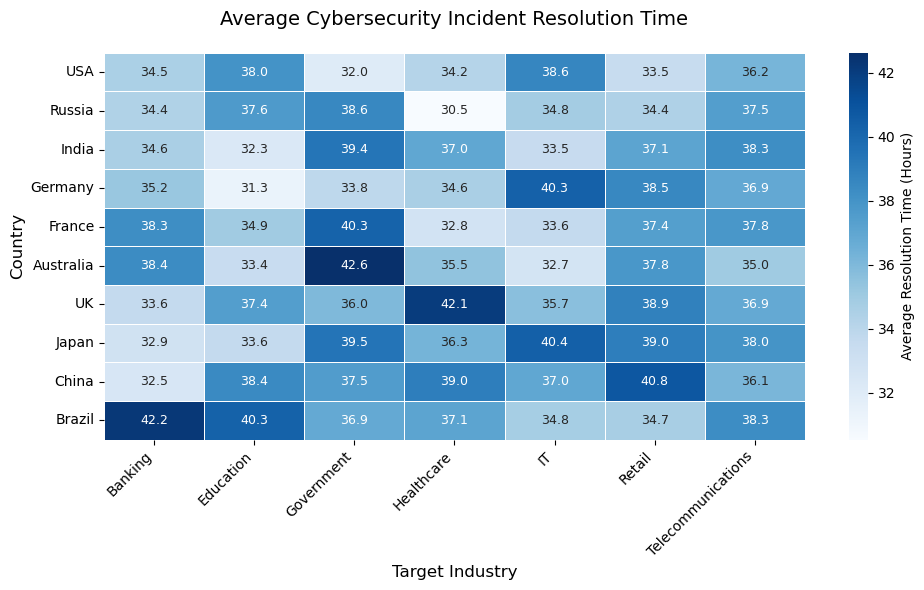

In [33]:

# Filter for countries with enough data
country_counts = dataset['Country'].value_counts()
significant_countries = country_counts[country_counts > 10].index.tolist()
dataset_filtered = dataset[dataset['Country'].isin(significant_countries)]

# Group to find the average incident resolution time
avg_resolution_filtered = dataset_filtered.groupby(['Country', 'Target Industry'])['Incident Resolution Time (in Hours)'].mean().reset_index()

# Sort countries by overall average resolution time
country_order = dataset_filtered.groupby('Country')['Incident Resolution Time (in Hours)'].mean().sort_values().index

# Create pivot table for heatmap
pivot_sorted = avg_resolution_filtered.pivot(index='Country', 
                                              columns='Target Industry', 
                                              values='Incident Resolution Time (in Hours)').reindex(country_order)

# Plotting the heatmap
plt.figure(figsize=(10, 6))
ax = sns.heatmap(pivot_sorted, 
                 cmap='Blues',  # Blue color scale
                 annot=True, 
                 fmt=".1f",
                 linewidths=.5,
                 cbar_kws={'label': 'Average Resolution Time (Hours)'},
                 annot_kws={"size": 9})

ax.set_title('Average Cybersecurity Incident Resolution Time', pad=20, size=14)
ax.set_xlabel('Target Industry', size=12)
ax.set_ylabel('Country', size=12)
plt.xticks(rotation=45, ha='right', size=10)
plt.yticks(size=10)
plt.tight_layout()
plt.show()


### Findings:
- Government and Healthcare sectors generally take longer to resolve incidents—seen with higher times in Brazil, Australia, UK, and France.
- Countries like Japan, China, and Russia show efficient response times, particularly in Banking and Healthcare.
- Some countries like Brazil and France show consistently higher resolution times, which could indicate resource or capacity constraintGovernments and Healthcare institutions need stronger automated response tools and better-trained cybersecurity personnel.


### Recommendation:
- Governments and Healthcare institutions need stronger automated response tools and better-trained cybersecurity personnel.
- Countries with faster response times (e.g., Russia, Japan, China) should collaborate with slower countries to share strategies, tools, and best practices.

    

## 6. Defense Mechanisms are Widely Used and their Effectiveness

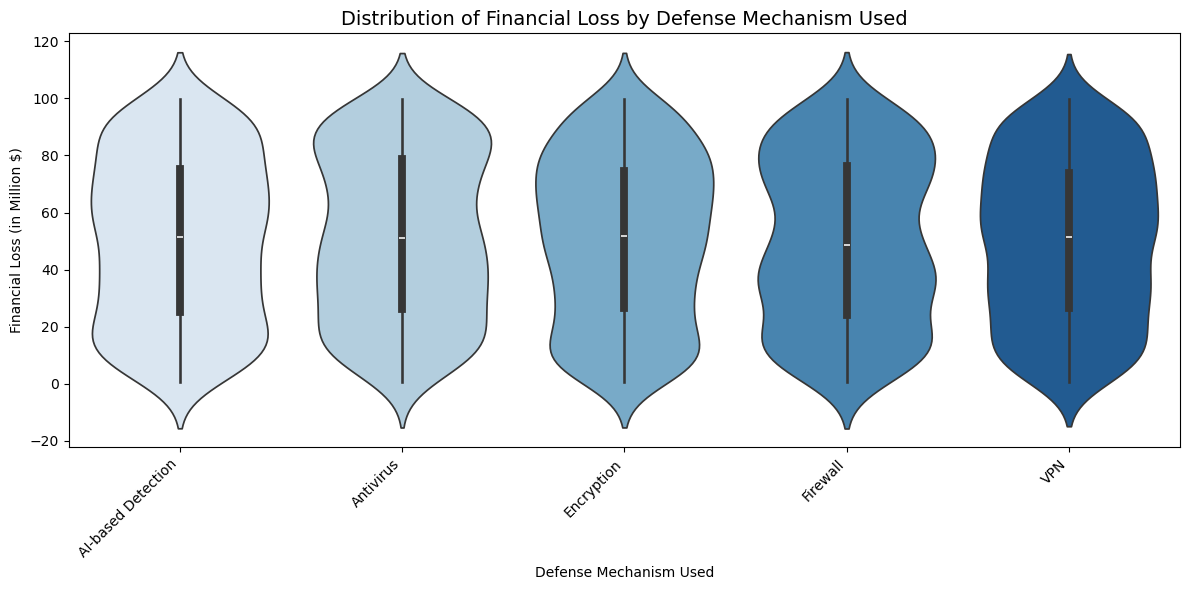

In [36]:

# Filter out rows with missing data
filtered_data = dataset[['Defense Mechanism Used', 'Financial Loss (in Million $)', 'Incident Resolution Time (in Hours)']].dropna()

# Set up the figure
plt.figure(figsize=(12, 6))

# Violin plot: Financial Loss by Defense Mechanism (in shades of blue)
sns.violinplot(data=filtered_data, 
               x='Defense Mechanism Used', 
               y='Financial Loss (in Million $)', 
               palette='Blues')

plt.title('Distribution of Financial Loss by Defense Mechanism Used', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Findings:
- Encryption appears to be one of the more effective and consistent defense mechanisms in reducing financial losses.
- AI-based Detection and Antivirus, though widely used, show high variability, meaning their effectiveness might depend heavily on configuration or context.
- Firewall and VPN show moderate performance, but not as effective in consistently minimizing losses.


### Recommendation:
- Encourage global adoption of encryption as a foundational layer of defense, especially for sensitive data.
- Governments and industries should not rely on a single defense mechanism instead, adopt a multi-layered security architecture combining encryption, firewalls, AI, VPN, etc.

## Developing a Predictive Model for Cyberattack Source

In [39]:
# Select relevant columns for prediction
features = ['Country','Attack Type', 'Target Industry','Financial Loss (in Million $)', 'Number of Affected Users', 'Security Vulnerability Type', 'Defense Mechanism Used',
            'Incident Resolution Time (in Hours)']
    
target = 'Attack Source'

# Drop rows with missing values in the relevant columns
prediction_data = dataset[features + [target]].dropna()

# Define X and y
X = prediction_data[features]
y = prediction_data[target]

# Display the first few rows of the data being used for prediction
prediction_data.head()

,Country,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours),Attack Source
0,China,Phishing,Education,80.53,773169,Unpatched Software,VPN,63,Hacker Group
1,China,Ransomware,Retail,62.19,295961,Unpatched Software,Firewall,71,Hacker Group
2,India,Man-in-the-Middle,IT,38.65,605895,Weak Passwords,VPN,20,Hacker Group
3,UK,Ransomware,Telecommunications,41.44,659320,Social Engineering,AI-based Detection,7,Nation-state
4,Germany,Man-in-the-Middle,IT,74.41,810682,Social Engineering,VPN,68,Insider


In [40]:
# Encoding the Categorical Colunms
encoded_dataset = pd.get_dummies(dataset, columns=[
    'Country', 
    'Attack Type', 
    'Security Vulnerability Type', 
    'Defense Mechanism Used'
])


In [41]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
dataset["Country"] = encoder.fit_transform(dataset["Country"])
dataset["Attack Type"] = encoder.fit_transform(dataset["Attack Type"])
dataset["Target Industry"] = encoder.fit_transform(dataset["Target Industry"])
dataset["Attack Source"] = encoder.fit_transform(dataset["Attack Source"])
dataset["Security Vulnerability Type"] = encoder.fit_transform(dataset["Security Vulnerability Type"])
dataset["Defense Mechanism Used"] = encoder.fit_transform(dataset["Defense Mechanism Used"])


### Support Vector Machine (SVM)

In [43]:

# Define features and target variable
features = ["Country", "Financial Loss (in Million $)", "Defense Mechanism Used", "Incident Resolution Time (in Hours)"]
target = "Attack Source"


# Encode target variable (Attack Source)
label_encoder = LabelEncoder()
dataset[target] = label_encoder.fit_transform(dataset[target])

# Split data
X = dataset[features]
y = dataset[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features (important for SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train SVM model
svm_model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)  # Experiment with different kernels
svm_model.fit(X_train, y_train)

# Make predictions
y_pred = svm_model.predict(X_test)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))


Model Accuracy: 0.28
Classification Report:
              precision    recall  f1-score   support

           0       0.31      0.09      0.14       146
           1       0.27      0.40      0.32       143
           2       0.30      0.47      0.37       154
           3       0.25      0.17      0.20       157

    accuracy                           0.28       600
   macro avg       0.28      0.28      0.26       600
weighted avg       0.28      0.28      0.26       600



### Visualizing the Model

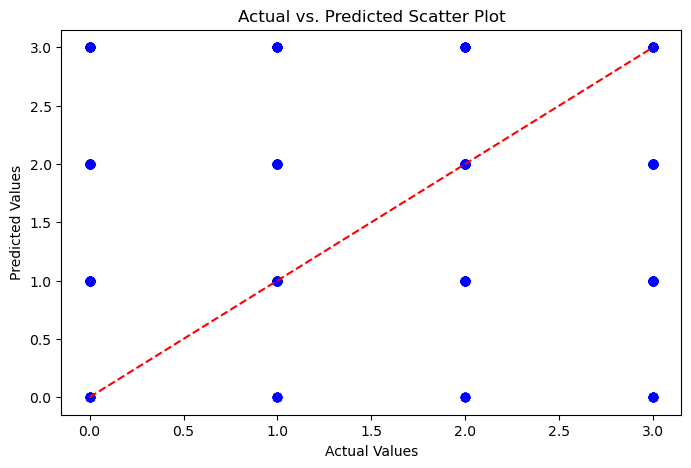

In [45]:
import matplotlib.pyplot as plt

# Scatter plot of actual vs predicted values
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.7, color="blue")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color="red", linestyle="--")  # Perfect predictions line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Scatter Plot")
plt.show()


### Findings

- Many blue dots are scattered away from the red line, indicating prediction errors.
  
- Multiple actual values share the same prediction (e.g., at Actual = 2, the predictions are scattered), which suggests the model may be oversimplifying or failing to generalize

### Recommendations

- Consider feature engineering to improve predictive power.
- Use cross-validation to check for overfitting and generalization across multiple data splits.

## Key Achievements
- Successfully conducted an in-depth analysis of cybersecurity incident patterns across multiple countries and industries.

- Identified the average incident resolution time per country and industry, revealing operational strengths and weaknesses.

- Developed visualizations (e.g., heatmaps, pie charts, violin plots) that clearly communicate complex data findings to stakeholders.

## Challenges and Opportunities
Challenges:

- Difficulty in achieving high predictive accuracy due to complex and overlapping factors influencing cyber incidents.

- Encoding categorical data and dealing with multicollinearity posed technical barriers during preprocessing.

Opportunities:

- Enhanced data collection standards can significantly improve future analytical efforts.

- Countries and industries with longer incident resolution times represent opportunities for investment in cyber readiness.

- The dataset provides a foundation for benchmarking and developing risk assessment tools tailored to specific sectors.



## Conclusion

The analysis of the cybersecurity dataset reveals important patterns across countries, industries, and security measures. Countries vary significantly in how quickly they resolve incidents, and certain industries experience longer resolution times, indicating potential vulnerabilities or complexities in their systems. The frequency and financial impact of cyber attacks also differ based on the type of attack and the defense mechanisms used. These findings underscore the importance of proactive cybersecurity strategies and the need for tailored approaches depending on geographic and industry-specific risks.

